# Training a 1D-CNN model in PyTorch to classify brain activities from EEG.


### Setp


In [1]:
import re
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn import preprocessing, model_selection
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Python executable:", __import__("sys").executable)
print("Torch version:", torch.__version__)
print("Device:", DEVICE)


Python executable: /opt/anaconda3/envs/py310/bin/python
Torch version: 2.2.2
Device: cpu


### Constants and configs


In [166]:
RAW_PATH = Path("EEG/eeg-data.csv")
LABELS_JSON_PATH = Path("labels.json")
REPORT_DIR = Path("outputs/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

DEBUG = False
DEBUG_SIZE = 1000
USE_MAJOR_CLASSES = True
SEQ_LEN = 512
BATCH_SIZE = 128
MAX_EPOCHS = 20
EARLY_STOP_PATIENCE = 10
LR = 1e-3
WEIGHT_DECAY = 1e-3
DROPOUT = 0.25
LABEL_SMOOTHING = 0.08
MAX_GRAD_NORM = 1.0

print("Raw exists:", RAW_PATH.exists())
print("labels.json exists:", LABELS_JSON_PATH.exists())
print("Report dir:", REPORT_DIR)

Raw exists: True
labels.json exists: True
Report dir: outputs/reports


## Utility functions


In [3]:
def parse_num_list(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text[0] == "[" and text[-1] == "]":
        text = text[1:-1]
    arr = np.fromstring(text, sep=",", dtype=np.float32)
    if arr.size == 0:
        return None
    return arr


def fix_len(arr, n):
    if arr is None:
        return None
    if arr.size == n:
        return arr.astype(np.float32)
    if arr.size > n:
        return arr[:n].astype(np.float32)
    out = np.zeros(n, dtype=np.float32)
    out[: arr.size] = arr
    return out


def power_to_seq(power, n=512):
    if power is None:
        return None
    power = fix_len(power, 8)
    x_old = np.arange(8, dtype=np.float32)
    x_new = np.linspace(0, 7, n, dtype=np.float32)
    return np.interp(x_new, x_old, power).astype(np.float32)


if not LABELS_JSON_PATH.exists():
    raise FileNotFoundError(f"Missing label mapping file: {LABELS_JSON_PATH}")

_RAW_LABEL_MAP = json.loads(LABELS_JSON_PATH.read_text(encoding="utf-8"))


def _resolve_label_once(src: str, label_map: dict, cache: dict) -> str:
    if src in cache:
        return cache[src]

    seen = set()
    cur = src
    while cur in label_map and cur not in seen:
        seen.add(cur)
        cur = label_map[cur]

    cache[src] = cur
    return cur


# Flatten any chained mappings exactly once for O(1) runtime lookup.
_RESOLVED_LABEL_MAP = {}
for _key in _RAW_LABEL_MAP:
    _resolve_label_once(_key, _RAW_LABEL_MAP, _RESOLVED_LABEL_MAP)

# Optional case-insensitive support.
_RESOLVED_LABEL_MAP_LOWER = {k.lower(): v for k, v in _RESOLVED_LABEL_MAP.items()}


def to_major_class(label: str) -> str:
    s = str(label).strip()
    if not s:
        return s

    mapped = _RESOLVED_LABEL_MAP.get(s)
    if mapped is not None:
        return mapped

    mapped = _RESOLVED_LABEL_MAP_LOWER.get(s.lower())
    if mapped is not None:
        return mapped

    # Fast fallback for unseen labels.
    base = re.split(r"[-_]", s)[0]
    base = re.sub(r"\d+$", "", base)
    return base or s

## Lodaing the data


In [4]:
eeg_data = pd.read_csv(RAW_PATH, converters={"eeg_power": parse_num_list, "raw_values": parse_num_list})
print("Data shape:", eeg_data.shape)
print("Columns:", eeg_data.columns)

Data shape: (30013, 13)
Columns: Index(['Unnamed: 0', 'id', 'indra_time', 'browser_latency', 'reading_time',
       'attention_esense', 'meditation_esense', 'eeg_power', 'raw_values',
       'signal_quality', 'createdAt', 'updatedAt', 'label'],
      dtype='object')


In [5]:
# Let's drop the unwanted/unnecessary columns:
eeg_data = eeg_data[['id', 'eeg_power', 'raw_values', 'label']]
print("Data shape after dropping unnecessary columns:", eeg_data.shape)

# Classes in the data:
eeg_data['label'].value_counts(dropna=False)

Data shape after dropping unnecessary columns: (30013, 4)


label
unlabeled            20054
relax                  934
music                  932
video-ver2             481
thinkOfItems-ver2      481
                     ...  
colorRound4-5           32
colorRound4-6           32
colorRound4-2           30
colorRound4-4           29
colorRound4-1           29
Name: count, Length: 68, dtype: int64

In [6]:
# we drop the "unlabeled" samples:
eeg_data = eeg_data[eeg_data['label'] != 'unlabeled']
print("Data shape after dropping unlabeled:", eeg_data.shape)

Data shape after dropping unlabeled: (9959, 4)


In [7]:
# collate the minor classes into major ones:
eeg_data['label'] = eeg_data['label'].map(to_major_class)
eeg_data.reset_index(inplace=True)
print(f"Data shape after collating minor classes into major ones: {eeg_data.shape}")
print(f"Unique classes after collating minor classes into major ones: \n\t{len(eeg_data['label'].unique())}")

Data shape after collating minor classes into major ones: (9959, 5)
Unique classes after collating minor classes into major ones: 
	19


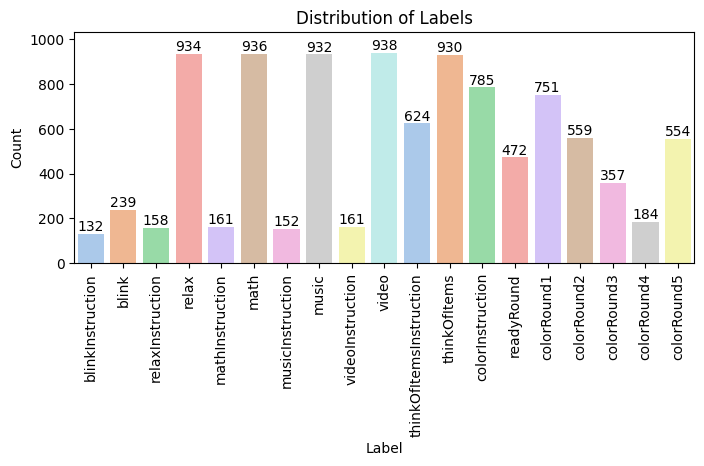

In [8]:
plt.figure(figsize=(8, 3))
sns.countplot(x='label', data=eeg_data, palette='pastel', hue='label')
for label in eeg_data.label.value_counts().keys():
    count = eeg_data[eeg_data.label == label].shape[0]
    plt.text(label, count, str(count), ha='center', va='bottom', rotation=0)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.ylim(0, max(eeg_data['label'].value_counts()) * 1.1)
plt.show()

## Normalizing the class imbalanceness

### Method 1. Simply assigning the 1-complement proportion of each class (naive method).

### Method 2. Normalizing the class weights from Mehotd 1 with (C - 1), where C is the number of classes.

### Method 3: Normlized inverse of class proportions (reverse distribution sould be observed!).


Mean of complementary: 0.9474 	 STD of complementary: 0.0325
Mean of normalized   : 0.0526 	 STD of normalized   : 0.0018


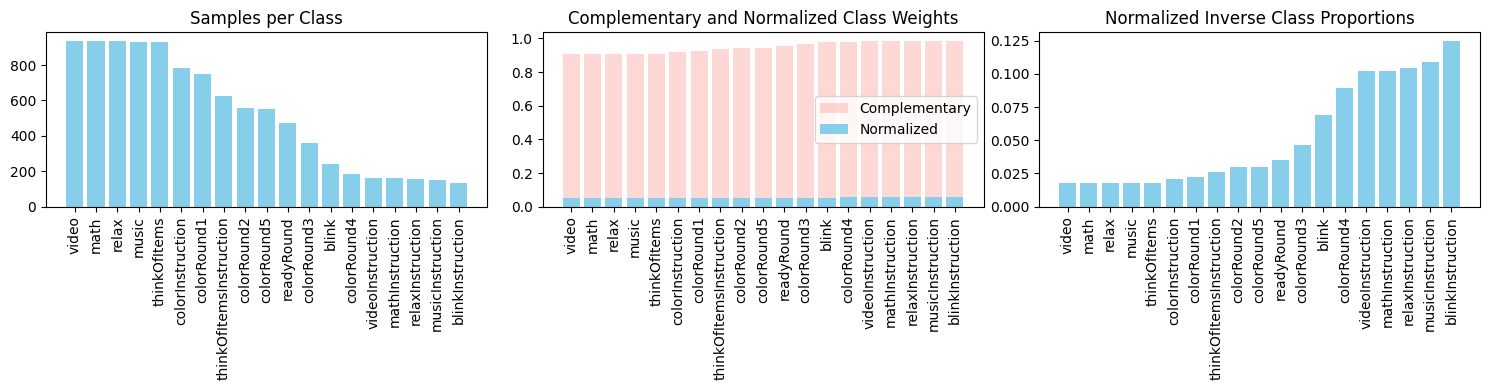

In [61]:
num_classes = len(eeg_data['label'].unique())
# print(f"Number of unique classes: {num_classes}")
sample_per_class = eeg_data['label'].value_counts()
class_proportions = eeg_data['label'].value_counts(normalize=True)

# Method 1: class weight = 1 - class proportion 
complementary_class_weights = (1.0 - class_proportions)

# Method 2: class weight = (1 - class proportion) / (num_classes - 1)
normalized_class_weights = complementary_class_weights / (num_classes - 1)

print(f'Mean of complementary: {complementary_class_weights.mean():.4f} \t STD of complementary: {complementary_class_weights.std():.4f}')
print(f'Mean of normalized   : {normalized_class_weights.mean():.4f} \t STD of normalized   : {normalized_class_weights.std():.4f}')

# Method 3: class weight = 1 / class proportion
normalized_inverse_proportions = 1.0 / (class_proportions + 1e-8)
normalized_inverse_proportions = normalized_inverse_proportions / normalized_inverse_proportions.sum()

# print("Class proportions:\n", class_proportions)
# print("Class weights:\n", normalized_class_weights)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].bar(sample_per_class.index, sample_per_class.values, color='skyblue')
axs[0].set_title('Samples per Class')
axs[0].set_xticks(ticks=range(len(sample_per_class.index)))
axs[0].set_xticklabels(labels=sample_per_class.index, rotation=90)

axs[1].bar(complementary_class_weights.index, complementary_class_weights.values, color='salmon', alpha=0.3, label='Complementary')
axs[1].bar(normalized_class_weights.index, normalized_class_weights.values, color='skyblue', label='Normalized')
axs[1].set_title('Complementary and Normalized Class Weights')
axs[1].set_xticks(ticks=range(len(normalized_class_weights.index)))
axs[1].set_xticklabels(labels=normalized_class_weights.index, rotation=90)
axs[1].legend(loc='right')

axs[2].bar(normalized_inverse_proportions.index, normalized_inverse_proportions.values, color='skyblue')
axs[2].set_title('Normalized Inverse Class Proportions')
axs[2].set_xticks(ticks=range(len(normalized_inverse_proportions.index)))
axs[2].set_xticklabels(labels=normalized_inverse_proportions.index, rotation=90)

plt.tight_layout()
plt.show()

## Normalizing the raw values


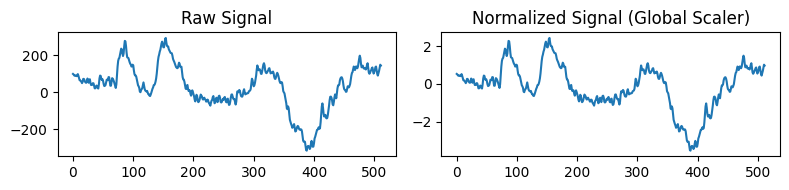

Scaler mean: 44.4823, scale: 102.0413


In [167]:
# Fit scaler ONCE on all flattened data, then apply to each sample
all_raw_values = np.concatenate([x for x in eeg_data['raw_values'] if x is not None])
scaler = preprocessing.StandardScaler()
scaler.fit(all_raw_values.reshape(-1, 1))

# Now transform each sample using the fitted scaler
eeg_data['normalized_raw_values'] = eeg_data['raw_values'].apply(
    lambda x: scaler.transform(x.reshape(-1, 1)).flatten() if x is not None else None
)

fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(eeg_data['raw_values'][0], label='Raw Values')
axs[1].plot(eeg_data['normalized_raw_values'][0], label='Normalized Raw Values')
axs[0].set_title('Raw Signal')
axs[1].set_title('Normalized Signal (Global Scaler)')
plt.tight_layout()
plt.show()

print(f"Scaler mean: {scaler.mean_[0]:.4f}, scale: {scaler.scale_[0]:.4f}")


# Dataloaders for train/val/test


In [168]:
debug_size = DEBUG_SIZE if DEBUG else len(eeg_data)
label_encoder = preprocessing.LabelEncoder().fit(eeg_data['label'][:debug_size])

class EEGDataset(torch.utils.data.Dataset):
    def __init__(self, data: pd.DataFrame, label_encoder: preprocessing.LabelEncoder, seq_len: int = 512):
        self.data = data
        self.label_encoder = label_encoder
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        raw_values = row['normalized_raw_values']
        if raw_values is None:
            raw_values = np.zeros(self.seq_len, dtype=np.float32)
        else:
            raw_values = fix_len(raw_values, self.seq_len)
        
        label = row['label']
        label_id = self.label_encoder.transform([label])[0]
        
        x = torch.tensor(raw_values, dtype=torch.float32).unsqueeze(0)  # Shape: (1, seq_len)
        y = torch.tensor(label_id, dtype=torch.long)
        
        return x, y

train_data, val_data = model_selection.train_test_split(
    eeg_data[:debug_size], 
    test_size=0.2, 
    stratify=eeg_data['label'][:debug_size],
    random_state=42)
print("Train shape:", train_data.shape)
print("Val shape:", val_data.shape)

train_ds = EEGDataset(train_data, label_encoder=label_encoder, seq_len=SEQ_LEN)
val_ds = EEGDataset(val_data, label_encoder=label_encoder, seq_len=SEQ_LEN)

train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

print('Batches | train:', len(train_loader), 'val:', len(val_loader))

Train shape: (7967, 6)
Val shape: (1992, 6)
Batches | train: 63 val: 16


# 1D-CNN Model


In [157]:
class EEG1DCNN(nn.Module):
    def __init__(self, num_classes, in_channels=1, seq_len=512, dropout=0.25):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(16),

            nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.AdaptiveAvgPool1d(1),
            nn.Dropout(dropout),
            nn.Flatten()
        )
        
        # Infer flattened size once from a dummy input so the architecture stays flexible.
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, seq_len)
            conv_out = self.conv(dummy)
            flat_dim = conv_out.numel()

        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # Flatten
        return self.classifier(x)
    
def train(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)

    return total_loss / len(dataloader.dataset)

def evaluate(model, dataloader, criterion):
    eval_metrics = {}
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)

            all_labels.append(labels.cpu())
            all_preds.append(outputs.cpu())

    avg_loss = total_loss / len(dataloader.dataset)
    all_labels = torch.cat(all_labels)
    all_preds = torch.cat(all_preds)
    
    all_preds_np = all_preds.numpy()
    all_labels_np = all_labels.numpy()
    
    eval_metrics['accuracy'] = accuracy_score(all_labels_np, all_preds_np.argmax(axis=1))
    eval_metrics['f1_macro'] = f1_score(all_labels_np, all_preds_np.argmax(axis=1), average='macro')
    
    # Top-k accuracy
    def top_k_accuracy(y_true, y_scores, k=2):
        """Compute top-k accuracy: is true label in top k predictions?"""
        top_k_preds = np.argsort(y_scores, axis=1)[:, -k:]  # Get indices of top k predictions
        return np.mean([y_true[i] in top_k_preds[i] for i in range(len(y_true))])
    
    if num_classes >= 2:
        eval_metrics['top_2_accuracy'] = top_k_accuracy(all_labels_np, all_preds_np, k=2)
    if num_classes >= 3:
        eval_metrics['top_3_accuracy'] = top_k_accuracy(all_labels_np, all_preds_np, k=3)
    
    try:
        probs = torch.softmax(torch.tensor(all_preds_np), dim=1)
        eval_metrics['auc_macro_ovr'] = roc_auc_score(all_labels_np, probs.numpy(), multi_class='ovr')
    except ValueError:
        eval_metrics['auc_macro_ovr'] = float('nan')
    return eval_metrics, avg_loss, all_labels, all_preds

In [170]:
weights = normalized_class_weights.values
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

model = EEG1DCNN(num_classes=num_classes, in_channels=1, seq_len=512).to(DEVICE)
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
from torchinfo import summary
summary(model, input_size=(1, 1, 512))
# print(f"Trainable params: {param_count:,}")

Layer (type:depth-idx)                   Output Shape              Param #
EEG1DCNN                                 [1, 19]                   --
├─Sequential: 1-1                        [1, 64]                   --
│    └─Conv1d: 2-1                       [1, 16, 256]              64
│    └─ReLU: 2-2                         [1, 16, 256]              --
│    └─BatchNorm1d: 2-3                  [1, 16, 256]              32
│    └─Conv1d: 2-4                       [1, 32, 128]              1,568
│    └─ReLU: 2-5                         [1, 32, 128]              --
│    └─BatchNorm1d: 2-6                  [1, 32, 128]              64
│    └─Conv1d: 2-7                       [1, 64, 64]               10,304
│    └─ReLU: 2-8                         [1, 64, 64]               --
│    └─BatchNorm1d: 2-9                  [1, 64, 64]               128
│    └─AdaptiveAvgPool1d: 2-10           [1, 64, 1]                --
│    └─Dropout: 2-11                     [1, 64, 1]                --
│    └─

In [171]:

# Initialize weights properly
def init_weights(model):
    """Initialize model weights with proper strategies"""
    for name, param in model.named_parameters():
        if param.dim() < 2:
            if 'bias' in name:
                nn.init.constant_(param, 0.0)
        else:
            if 'conv' in name:
                # Conv1d: He initialization
                nn.init.kaiming_normal_(param, mode='fan_out', nonlinearity='relu')
            else:
                # Linear: Xavier initialization
                nn.init.xavier_uniform_(param)

# Apply initialization
init_weights(model)

# Verify initialization
print("=" * 60)
print("Parameter Initialization Check")
print("=" * 60)

for name, param in model.named_parameters():
    if param.requires_grad:
        mean = param.data.mean().item()
        std = param.data.std().item()
        min_val = param.data.min().item()
        max_val = param.data.max().item()
        print(f"{name:40s} | mean={mean:8.5f} | std={std:8.5f} | [{min_val:8.5f}, {max_val:8.5f}]")

print("=" * 60)
print("  Initialization complete")
print("  Conv weights: He initialization (sqrt(2/fan_in))")
print("  Linear weights: Xavier/Glorot (uniform)")
print("  All biases: 0.0")


Parameter Initialization Check
conv.0.weight                            | mean=-0.01749 | std= 0.17998 | [-0.33446,  0.43563]
conv.0.bias                              | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
conv.2.weight                            | mean= 1.00000 | std= 0.00000 | [ 1.00000,  1.00000]
conv.2.bias                              | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
conv.3.weight                            | mean= 0.00044 | std= 0.14530 | [-0.45039,  0.46609]
conv.3.bias                              | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
conv.5.weight                            | mean= 1.00000 | std= 0.00000 | [ 1.00000,  1.00000]
conv.5.bias                              | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
conv.6.weight                            | mean= 0.00043 | std= 0.07972 | [-0.28012,  0.34759]
conv.6.bias                              | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
conv.8.weight      

# Training loop


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = {'train_loss': [], 'val_f1': [], 'val_acc': [], 'val_auc': [], 'val_top2_acc': [], 'val_top3_acc': []}
best_state = None
best_val_f1 = -1.0
epochs_no_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_metrics, avg_loss, all_labels, all_preds = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_f1'].append(val_metrics['f1_macro'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_auc'].append(val_metrics['auc_macro_ovr'])
    history['val_top2_acc'].append(val_metrics.get('top_2_accuracy', float('nan')))
    history['val_top3_acc'].append(val_metrics.get('top_3_accuracy', float('nan')))

    top2_str = f" | top2={val_metrics.get('top_2_accuracy', float('nan')):.4f}" if 'top_2_accuracy' in val_metrics else ""
    top3_str = f" | top3={val_metrics.get('top_3_accuracy', float('nan')):.4f}" if 'top_3_accuracy' in val_metrics else ""
    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | loss={train_loss:.4f} | val_f1={val_metrics['f1_macro']:.4f} | val_acc={val_metrics['accuracy']:.4f} | val_auc={val_metrics['auc_macro_ovr']:.4f}{top2_str}{top3_str}")

    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print('Best val macro-F1:', round(best_val_f1, 4))


Epoch 01/20 | loss=2.7697 | val_f1=0.0531 | val_acc=0.1255 | val_auc=0.5810 | top2=0.2334 | top3=0.3399
Epoch 02/20 | loss=2.6929 | val_f1=0.0620 | val_acc=0.1325 | val_auc=0.6015 | top2=0.2430 | top3=0.3414
Epoch 03/20 | loss=2.6770 | val_f1=0.0551 | val_acc=0.1300 | val_auc=0.6136 | top2=0.2349 | top3=0.3484
Epoch 04/20 | loss=2.6618 | val_f1=0.0703 | val_acc=0.1411 | val_auc=0.6115 | top2=0.2585 | top3=0.3559
Epoch 05/20 | loss=2.6449 | val_f1=0.0600 | val_acc=0.1406 | val_auc=0.6290 | top2=0.2530 | top3=0.3519
Epoch 06/20 | loss=2.6332 | val_f1=0.0791 | val_acc=0.1526 | val_auc=0.6405 | top2=0.2656 | top3=0.3790
Epoch 07/20 | loss=2.6223 | val_f1=0.0771 | val_acc=0.1365 | val_auc=0.6360 | top2=0.2460 | top3=0.3584
Epoch 08/20 | loss=2.6122 | val_f1=0.0741 | val_acc=0.1486 | val_auc=0.6402 | top2=0.2666 | top3=0.3750
Epoch 09/20 | loss=2.5975 | val_f1=0.0709 | val_acc=0.1541 | val_auc=0.6452 | top2=0.2691 | top3=0.3750
Epoch 10/20 | loss=2.5941 | val_f1=0.0732 | val_acc=0.1526 | val

Batch shape: xb=torch.Size([128, 1, 512]), yb=torch.Size([128])
Accuracy on this batch: 0.1953


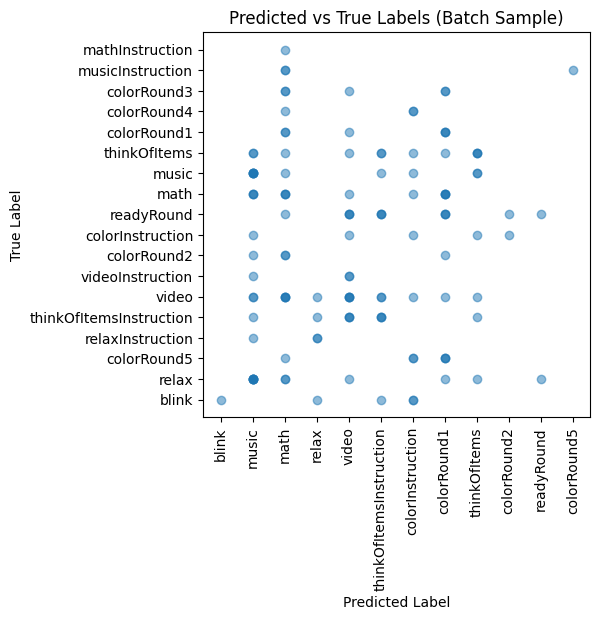

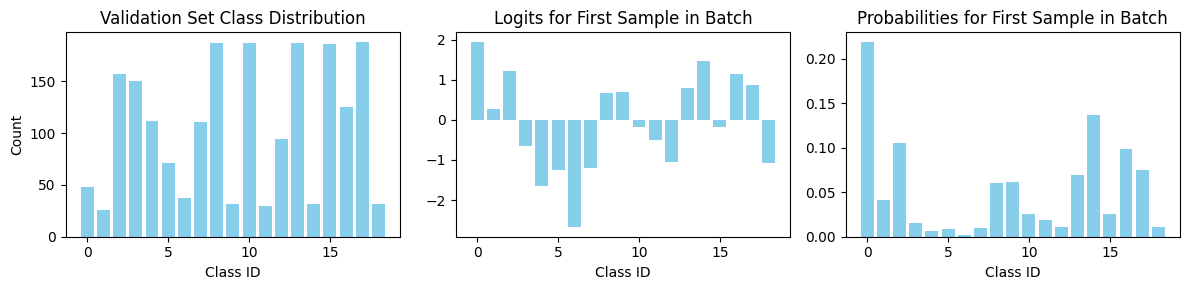

In [173]:
# one batch
xb, yb = next(iter(train_loader))
print(f"Batch shape: xb={xb.shape}, yb={yb.shape}")
# print(f"Label values in batch: {yb.unique().tolist()}")
# print(f"Label encoder classes: {label_encoder.classes_}")
# print(f"Num classes: {num_classes}")

# only going through forward pass
xb = xb.to(DEVICE)
yb = yb.to(DEVICE)
with torch.no_grad():
    logits = model(xb)
    probs = torch.softmax(logits, dim=1)
    preds = logits.argmax(dim=1)

# print(f"\nLogits shape: {logits.shape}")
# print(f"Logits sample: {logits[0]}")
# print(f"Probs sample: {probs[0]}")
# print(f"Predictions sample: {preds[:10]}")
# print(f"True labels sample: {yb[:10]}")
print(f"Accuracy on this batch: {(preds == yb).float().mean():.4f}")

predicted_labels = label_encoder.inverse_transform(preds.cpu().numpy())
true_labels = label_encoder.inverse_transform(yb.cpu().numpy())

plt.figure(figsize=(5, 5))
plt.scatter(predicted_labels, true_labels, alpha=0.5)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Predicted vs True Labels (Batch Sample)')
plt.xticks(rotation=90)
plt.show()

val_labels = []
for xb, yb in val_loader:
    val_labels.extend(yb.tolist())
val_labels = np.array(val_labels)
unique, counts = np.unique(val_labels, return_counts=True)
# for u, c in zip(unique, counts):
#     print(f"  Class {u}: {c} samples")

fig, axs = plt.subplots(1, 3, figsize=(12, 3))

axs[0].bar(unique, counts, color='skyblue')
axs[0].set_title('Validation Set Class Distribution')
axs[0].set_xlabel('Class ID')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=0)

axs[1].bar(range(len(logits[0])), logits[0], color='skyblue')
axs[1].set_title('Logits for First Sample in Batch')
axs[1].set_xlabel('Class ID')
axs[1].tick_params(axis='x', rotation=0)

axs[2].bar(range(len(probs[0])), probs[0], color='skyblue')
axs[2].set_title('Probabilities for First Sample in Batch')
axs[2].set_xlabel('Class ID')
axs[2].tick_params(axis='x', rotation=0)

fig.tight_layout()
plt.show()
